In [1]:
from svg_sampler import sample_from_svg
from matplotlib import pyplot as plt
import jax
import jax.numpy as jnp
from eventax.evnn import FFEvNN
from eventax.neuron_models import LIF, QIF
import equinox as eqx
import optax
import numpy as np
import matplotlib.pyplot as plt
import optimistix as opx
import math
jax.config.update("jax_enable_x64", True)

# Classification example

This example implements the **Yin–Yang experiment** from the paper [*Event-Based Backpropagation Can Compute Exact Gradients for Spiking Neural Networks*](https://arxiv.org/abs/2009.08378) by Wunderlich and Pehle.

The Yin–Yang dataset is a 2D classification problem where, based on an *x* and *y* coordinate, one of three classes must be predicted.  
Data points are randomly sampled from the Yin–Yang structure shown below:

<img src="yin_yang.svg" alt="Yin–Yang dataset" style="max-width: 300px; width: 10%; height: auto;" />

Following the paper, we temporally encode the dataset using spikes as follows.

Each sample produces five input spikes, one per input channel, with spike times:

$$
\begin{aligned}
t_0 &= X \cdot t_\text{in max}\\
t_1 &= Y \cdot t_\text{in max}\\
t_2 &= (1 - X) \cdot t_\text{in max} \\
t_3 &= (1 - Y) \cdot t_\text{in max} \\
t_4 &= 0
\end{aligned}
$$

where $t_\text{in max}$ is the maximum spike time for an input spike that determines the temporal scaling. We will also only simulate until $t_\text{in max}$.

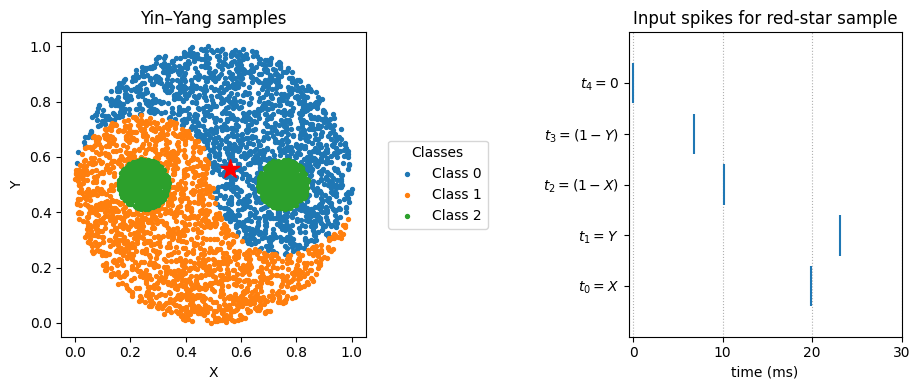

In [2]:
# create data

max_in_time = 30 # ms
train_samples = 5000
test_samples = 1000

data, targets = sample_from_svg("./yin_yang.svg", total_samples=train_samples,
                       sample_setting="equal_over_classes", overlap_mode="upper_only",
                       normalize=True, seed=1234)

data_val, targets_val = sample_from_svg("./yin_yang.svg", total_samples=test_samples,
                        sample_setting="equal_over_classes", overlap_mode="upper_only",
                        normalize=True, seed=1234)

data_test, targets_test = sample_from_svg("./yin_yang.svg", total_samples=test_samples,
                          sample_setting="equal_over_classes", overlap_mode="upper_only",
                          normalize=True, seed=1234)

def temporal_encoding(d, max_t):
    d = jnp.concatenate((d, 1 - d, jnp.zeros((d.shape[0], 1))), axis=1)
    d *= max_t
    d = d[..., None]
    return d

data_raw = data
data = temporal_encoding(data, max_in_time)
data_val = temporal_encoding(data_val, max_in_time)
data_test = temporal_encoding(data_test, max_in_time)

fig, (ax_scatter, ax_spikes) = plt.subplots(
    1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [2, 1]}
)

ax_scatter.set_title("Yin–Yang samples")
ax_scatter.set_aspect('equal', adjustable='box')
ax_scatter.set_xlabel("X")
ax_scatter.set_ylabel("Y")

classes = np.unique(np.asarray(targets))
for cls in classes:
    m = np.asarray(targets) == cls
    ax_scatter.scatter(data_raw[m, 0], data_raw[m, 1], s=8, label=f"Class {int(cls)}")

ax_scatter.scatter(data_raw[0, 0], data_raw[0, 1], marker='*', color='red', s=200.0, zorder=5)

ax_scatter.legend(
    title="Classes",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=True
)

t_sample = np.asarray(data[1, :, 0])
channels = np.arange(5)

ax_spikes.eventplot([[t] for t in t_sample],
                    lineoffsets=channels, linelengths=0.8)

ax_spikes.set_xlim(-0.5, max_in_time)
ax_spikes.set_ylim(-1, 5)
ax_spikes.set_xlabel("time (ms)")
ax_spikes.set_yticks(channels)
ax_spikes.set_yticklabels([r"$t_0=X$", r"$t_1=Y$", r"$t_2=(1-X)$", r"$t_3=(1-Y)$", r"$t_4=0$"])
ax_spikes.set_title("Input spikes for red-star sample")
ax_spikes.grid(True, axis='x', linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.show()

## Loss Function

We use the same cross entropy loss as in the paper 

$$
\mathcal{L} = -\frac{1}{N_{\text{batch}}} \sum_{i=1}^{N_{\text{batch}}} 
\bigg[ \log \bigg[ \frac{\exp\!\big(-t^{\text{post}}_{i,l(i)} / \tau_0\big)}
{\sum_{k=1}^{3} \exp\!\big(-t^{\text{post}}_{i,k} / \tau_0\big)} \bigg] 
+ \alpha \bigg[ \exp\!\bigg(\frac{t^{\text{post}}_{i,l(i)}}{\tau_1}\bigg) - 1 \bigg] \bigg],
$$

where $ t_{i, k}^{\text{post}}$ is the first spike time of neuron $k$ for the $i$th sample, $l(i)$ is the index of the correct label for the $i$th sample, $N_\text{batch}$ is the number of samples in a given batch and $\tau_0$ and $\tau_1$ are hyperparameters of the loss function. The first term corresponds to a cross-entropy loss function over the softmax function applied to the negative spike times (negative spike times as the class assignment is determined by the smallest spike time) and encourages an increase of the spike time difference between the label neuron and all other neurons. As the first term depends only on the relative spike times, the second term is a regularization term that encourages early spiking of the label neuron.

In [3]:
tau0, tau1, alpha = 0.5, 6.4, 3e-3

def loss_fn(model, spike_times_b, target_classes_b):
    def per_example(spike_times_single, target_class):
        out_times = model.ttfs(spike_times_single)
        out_times = jnp.where(jnp.isinf(out_times), max_in_time, out_times) # treat inf (no spike) as max_in_time for loss
        time_of_target = out_times[target_class]
        loss1 = jnp.exp(-time_of_target / tau0) / jnp.sum(jnp.exp(-out_times / tau0))
        loss2 = jnp.exp(time_of_target / tau1) - 1
        return -jnp.log(loss1 + alpha * loss2)

    per_ex_losses = jax.vmap(per_example)(spike_times_b, target_classes_b)
    return jnp.mean(per_ex_losses)


v_and_grad = eqx.filter_value_and_grad(loss_fn)

@eqx.filter_jit
def train_step(model, opt_state, in_times_b, target_classes_b):
    loss, grad = v_and_grad(model, in_times_b, target_classes_b)
    updates, opt_state = optimizer.update(
        grad, opt_state, params=eqx.filter(model, eqx.is_array)
    )
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


@eqx.filter_jit
def predict_batch(model, in_times_b):
    return jax.vmap(model.ttfs)(in_times_b)

## EvNN creation

We use a Feed forward EvNN with 20 layers and QIF neurons. As optimizer we choose Adam with a learning rate of $0.05$.

In [4]:
key = jax.random.PRNGKey(1234)

snn = FFEvNN(
        dtype=jnp.float64,
        layers=[20, 3],
        in_size=5,
        neuron_model=QIF,
        max_solver_time=max_in_time,
        key=key,
        solver_stepsize=0.05,
        tsyn=5.0,
        tmem=20.0,
        blim=1.0,
        wlim=40.0,
        wmean=20.0,
        max_event_steps=200,
)

optimizer = optax.adam(0.05)
optim_state = optimizer.init(snn)

In [5]:
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import FormatStrFormatter
from IPython.display import display

def make_train_figures(n_outputs):
    """Create the live-updating figures for training. Returns an opaque state dict."""
    fig_la, (axL, axA) = plt.subplots(1, 2, figsize=(10, 4), dpi=150, constrained_layout=True)
    (line_loss,) = axL.plot([], [], lw=2)
    (line_acc,) = axA.plot([], [], lw=2)
    axL.set(title="Train Loss", xlabel="epoch", ylabel="loss")
    axL.grid(True, alpha=0.3)
    axA.set(title="Val Accuracy", xlabel="epoch", ylabel="acc")
    axA.set_ylim(0, 1)
    axA.grid(True, alpha=0.3)

    n_cols = int(np.ceil(np.sqrt(n_outputs)))
    n_rows = int(np.ceil(n_outputs / n_cols))
    fig_lat, lat_axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 4, n_rows * 4),
        dpi=150, constrained_layout=True,
    )
    lat_axes = np.array(lat_axes).reshape(-1)
    for j in range(n_outputs, len(lat_axes)):
        lat_axes[j].axis("off")
    fig_lat.suptitle("Spike Latencies per Output", fontsize=12)
    fig_lat._cbar = None

    return dict(
        fig_la=fig_la, axL=axL, axA=axA,
        line_loss=line_loss, line_acc=line_acc,
        la_handle=display(fig_la, display_id=True),
        fig_lat=fig_lat, lat_axes=lat_axes,
        lat_handle=display(fig_lat, display_id=True),
        n_outputs=n_outputs,
    )

def update_train_figures(figs, loss_hist, acc_hist, X2, S):
    """Update both figures with current training state."""
    # loss / accuracy
    xs = range(1, len(loss_hist) + 1)
    figs["line_loss"].set_data(xs, loss_hist)
    figs["line_acc"].set_data(xs, acc_hist)
    figs["axL"].relim()
    figs["axL"].autoscale_view()
    figs["axA"].relim()
    figs["axA"].autoscale_view()
    figs["axA"].set_ylim(0, 1)
    figs["axA"].set_title(f"Val Accuracy (Best: {max(acc_hist) * 100:.2f}%)")
    figs["la_handle"].update(figs["fig_la"])

    # latency
    S = np.asarray(S)
    X2 = np.asarray(X2)
    C = figs["n_outputs"]
    fig_lat = figs["fig_lat"]
    lat_axes = figs["lat_axes"]

    valid = np.isfinite(S)
    first_spike = np.min(np.where(valid, S, np.inf), axis=1)
    first_neuron = np.argmin(np.where(valid, S, np.inf), axis=1)

    latencies = np.full(S.shape, np.nan)
    has_spike = np.isfinite(first_spike)
    np.subtract(S, first_spike[:, None], out=latencies,
                where=valid & has_spike[:, None])

    vmax = np.nanmax(latencies) if np.any(~np.isnan(latencies)) else 1.0
    norm = plt.Normalize(0, vmax)
    cmap = plt.get_cmap("viridis_r")

    for i, ax in enumerate(lat_axes[:C]):
        ax.cla()
        ax.set_title(f"Output Neuron {i}")
        ax.set_xlabel("Input Feature 1")
        ax.set_ylabel("Input Feature 2")

        vmask = valid[:, i]
        nmask = ~vmask

        if np.any(nmask):
            ax.scatter(X2[nmask, 0], X2[nmask, 1],
                       c="red", marker="x", alpha=0.7)
        if np.any(vmask):
            ax.scatter(X2[vmask, 0], X2[vmask, 1],
                       c=latencies[vmask, i], cmap=cmap, norm=norm, alpha=0.8)

        first_mask = vmask & (first_neuron == i)
        if np.any(first_mask):
            ax.scatter(X2[first_mask, 0], X2[first_mask, 1],
                       facecolors="#BA8E23", edgecolors="none",
                       s=25, marker=".", zorder=3)

    if fig_lat._cbar is not None:
        try:
            fig_lat._cbar.remove()
        except Exception:
            pass

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig_lat.colorbar(
        sm, ax=lat_axes[:C].tolist(),
        orientation="vertical", fraction=0.02, pad=0.04,
    )
    cbar.set_label("Latency (ms)")
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    fig_lat._cbar = cbar

    figs["lat_handle"].update(fig_lat)

## Training Loop

We train the network over 100 epochs with a batch size of 256.

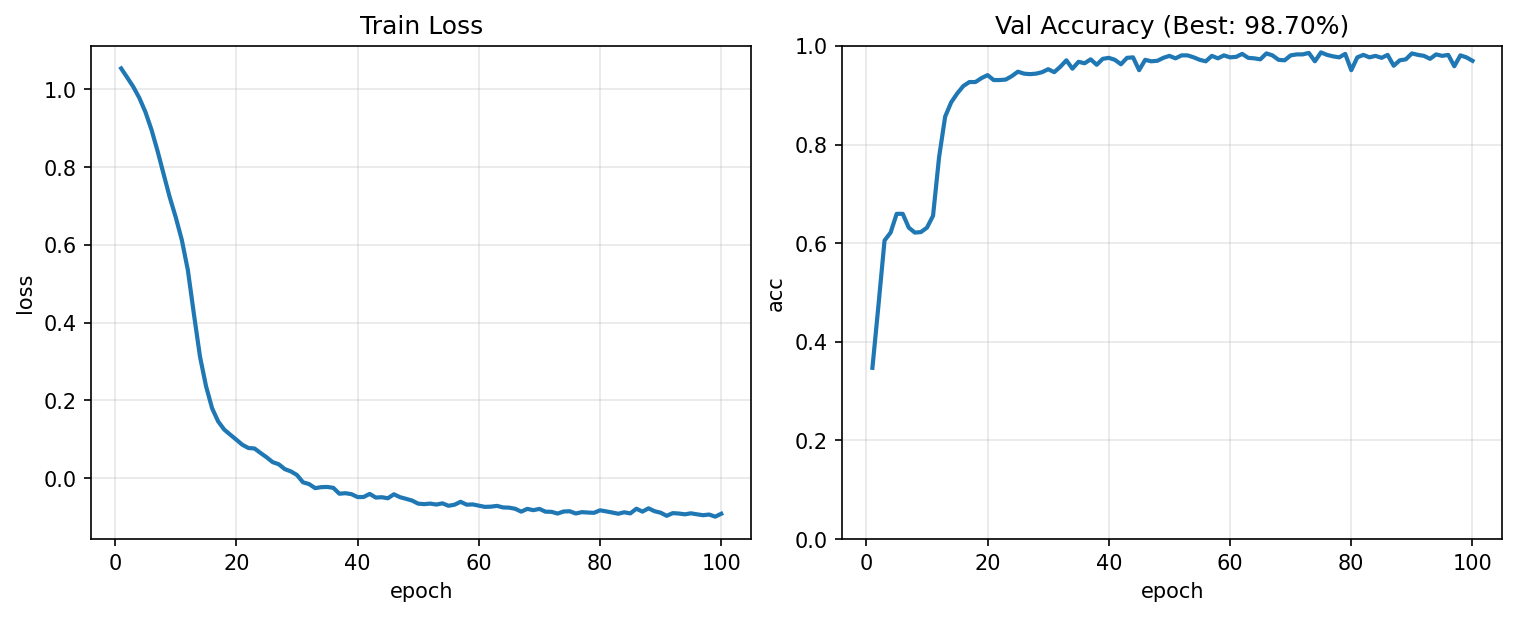

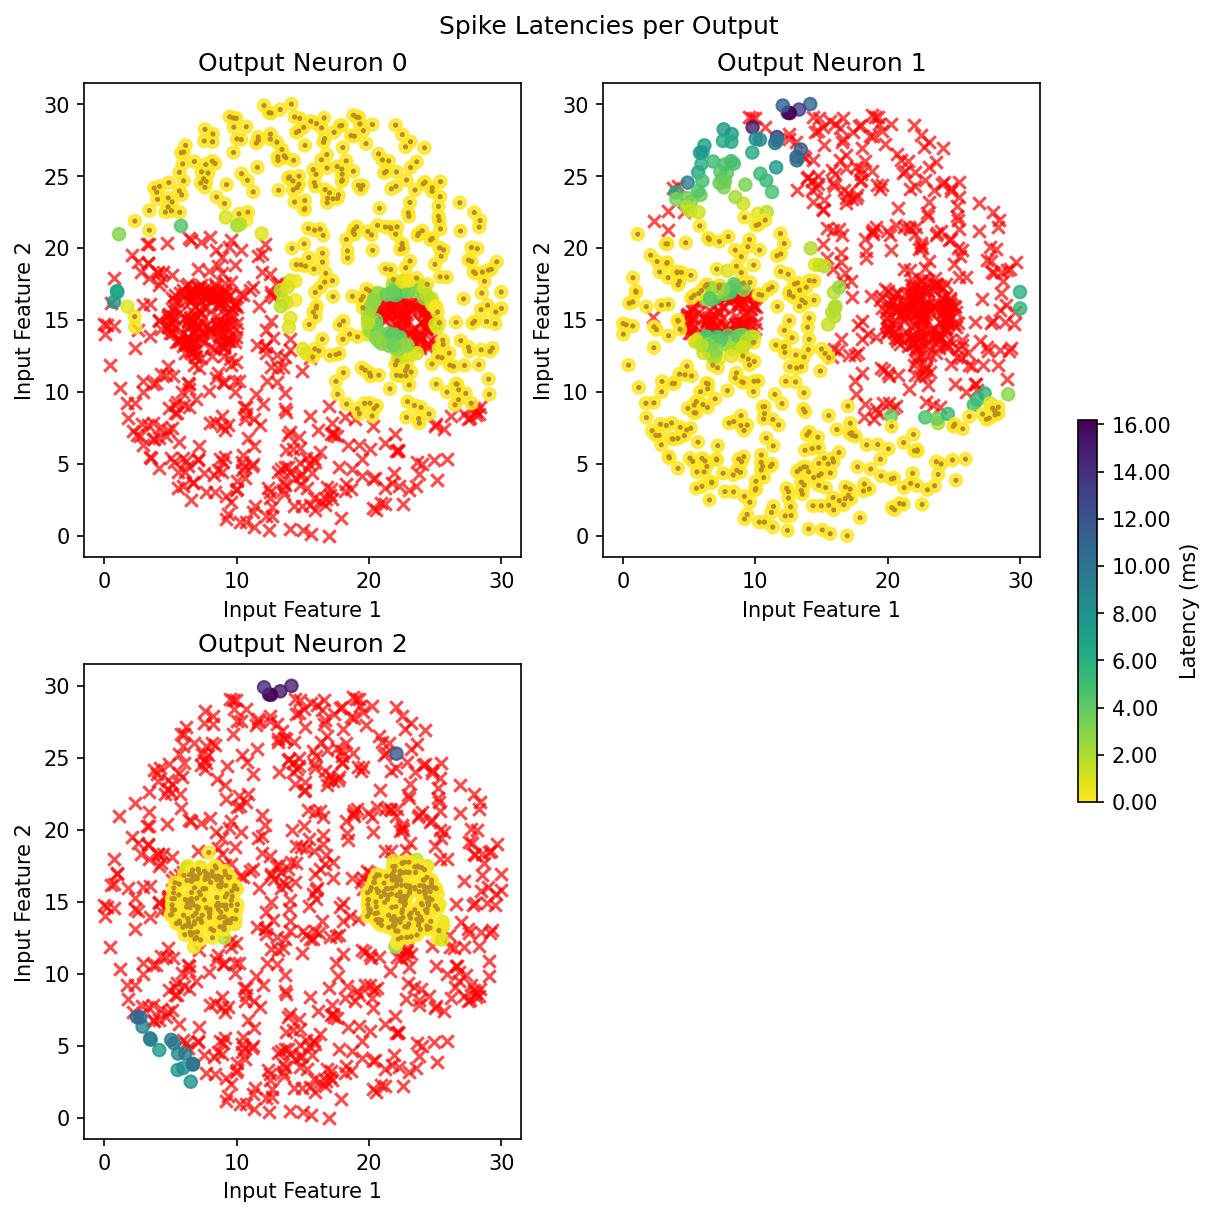

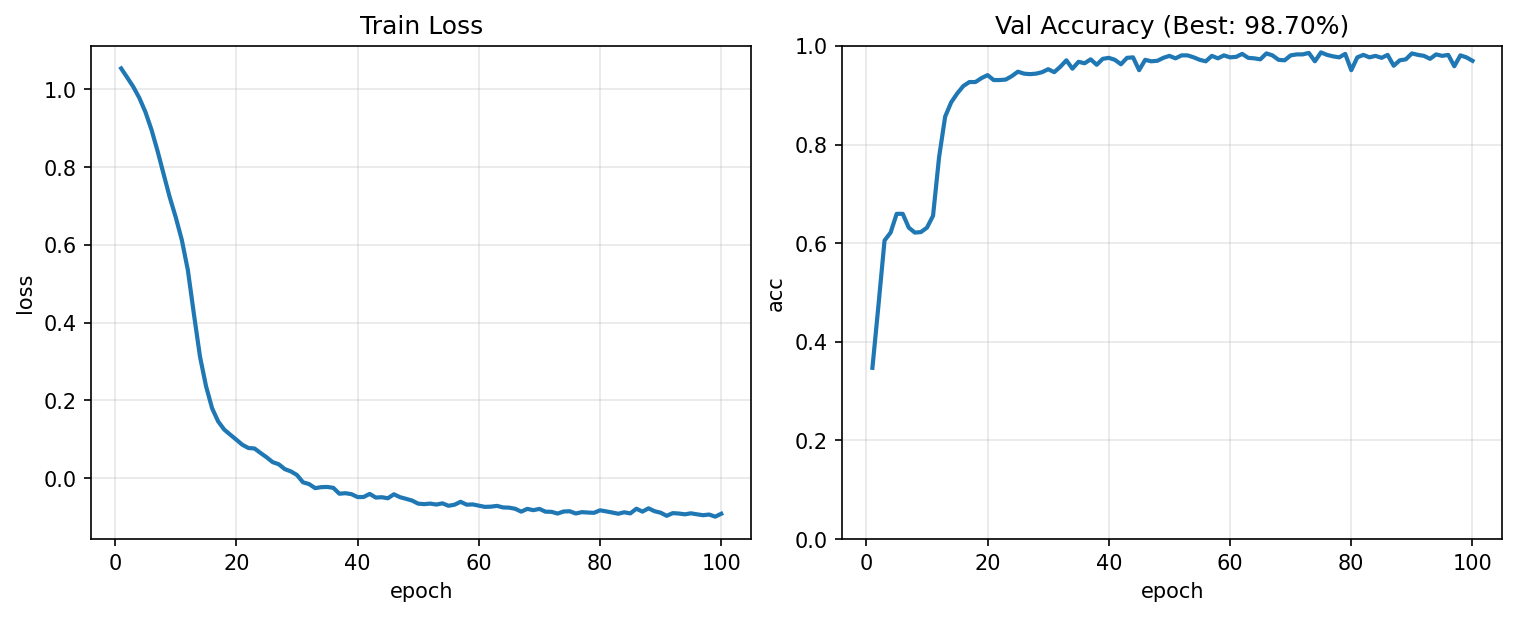

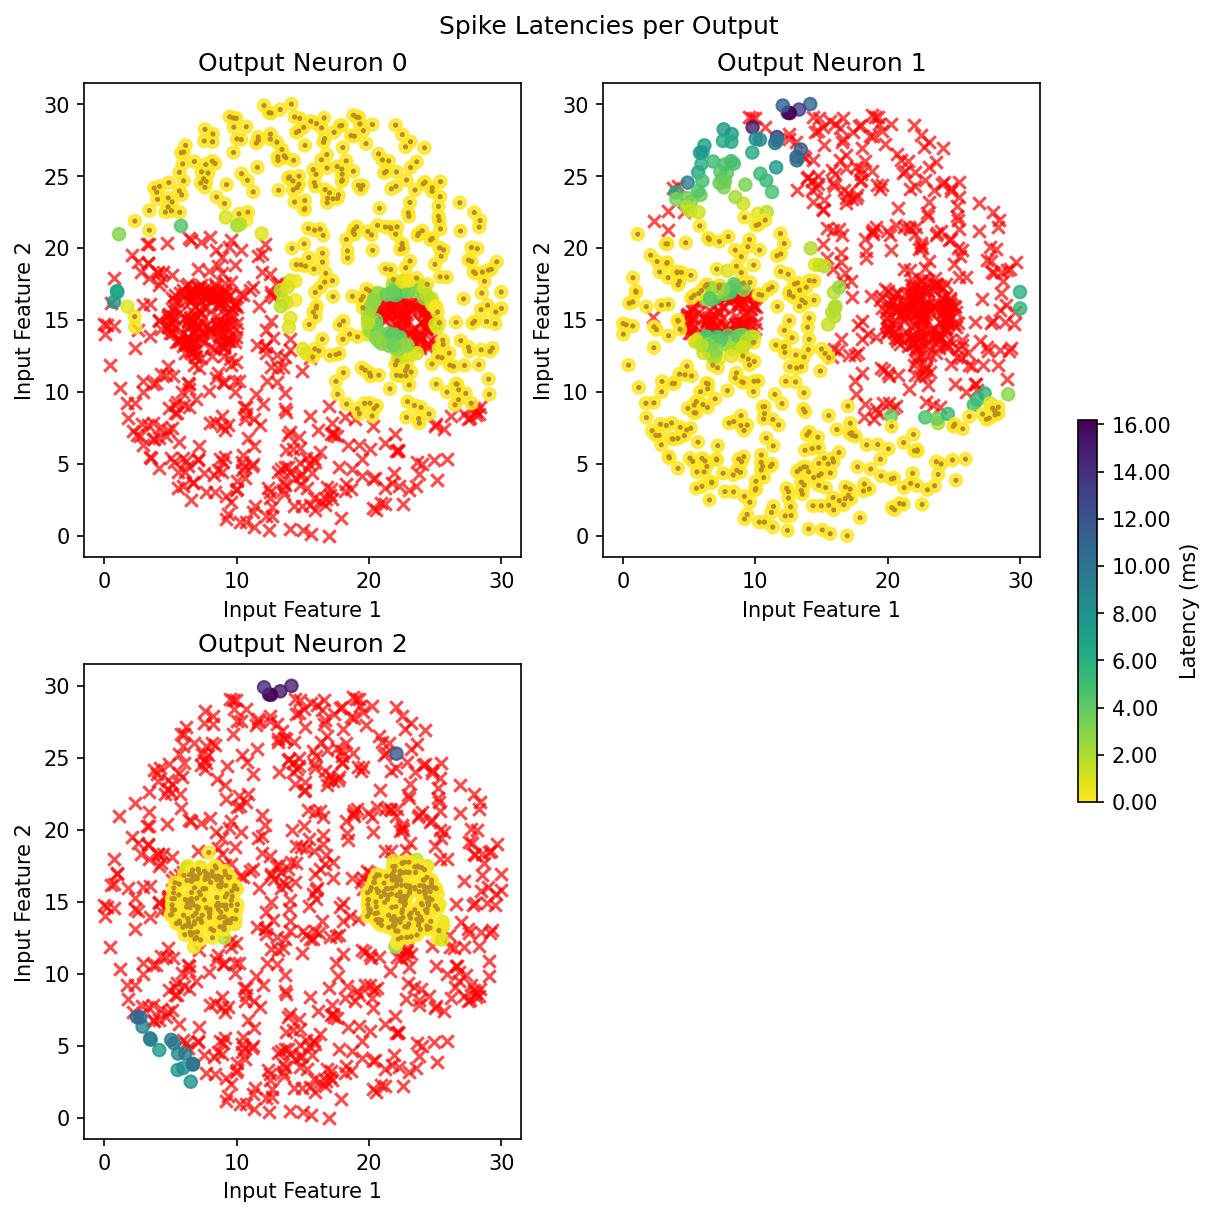

In [6]:
batch_size = 256
num_epochs = 100
loss_hist = []
acc_hist = []

N = data.shape[0]
steps_per_epoch = math.ceil(N / batch_size)
rng = key

figs = make_train_figures(n_outputs=3)

for epoch in range(1, num_epochs + 1):
    rng, sk = jax.random.split(rng)
    perm = jax.random.permutation(sk, N)
    X_shuf = data[perm]
    y_shuf = targets[perm]

    epoch_loss = 0.0
    for start in range(0, N, batch_size):
        xb = X_shuf[start:start + batch_size]
        yb = y_shuf[start:start + batch_size]
        snn, optim_state, batch_loss = train_step(snn, optim_state, xb, yb)
        epoch_loss += float(batch_loss)

    loss_hist.append(epoch_loss / steps_per_epoch)

    out = predict_batch(snn, data_val)
    pred = jnp.argmin(out, axis=-1)
    acc_hist.append(float(jnp.mean(pred == targets_val)))

    update_train_figures(figs, loss_hist, acc_hist, data_val[:, :2], out)